<a href="https://colab.research.google.com/github/nagapandi1982/Colab-projects/blob/main/Multivariate_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Can you build a multivariate linear regression model that can predict the product sales based on the advertising budget allocated to different channels. The features are TV Budget ($), Radio Budget ($), Newspaper Budget ($) and the output is Sales (units)
# The dataset is given below
# TV Budget ($),Radio Budget ($),Newspaper Budget ($),Sales (units)
# 230.1,37.8,69.2,22.1
# 44.5,39.3,45.1,10.4
# 17.2,45.9,69.3,9.3
# 151.5,41.3,58.5,18.5
# 180.8,10.8,58.4,12.9
# 8.7,48.9,75.0,7.2
# 57.5,32.8,23.5,11.8
# 120.2,19.6,11.6,13.2
# 144.1,16.0,40.3,15.6
# 111.6,12.6,37.9,12.2

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [7]:
data = pd.read_csv("https://raw.githubusercontent.com/nagapandi1982/Colab-projects/refs/heads/main/Sales%20Prediction%20-%20Television%20Companies.txt")
data.head()

,TV Budget ($),Radio Budget ($),Newspaper Budget ($),Sales (units)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [32]:
X = data.iloc[:, 0:3]
y = data.iloc[:, 3]
df = pd.concat([X, y.rename("y")], axis=1); df.columns = ["X1","X2","X3","y"]

# Ensure columns named as requested
assert set(["X1","X2","X3","y"]).issubset(df.columns), "Make sure df has X1, X2, X3, y"

X = df[["X1","X2","X3"]].to_numpy()
y = df["y"].to_numpy()

In [33]:
print (X)

[[230.1  37.8  69.2]
 [ 44.5  39.3  45.1]
 [ 17.2  45.9  69.3]
 [151.5  41.3  58.5]
 [180.8  10.8  58.4]
 [  8.7  48.9  75. ]
 [ 57.5  32.8  23.5]
 [120.2  19.6  11.6]
 [144.1  16.   40.3]
 [111.6  12.6  37.9]]


In [34]:
print (y)

[22.1 10.4  9.3 18.5 12.9  7.2 11.8 13.2 15.6 12.2]


In [31]:
model=LinearRegression()
model.fit(X,y)
print (model)

LinearRegression()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


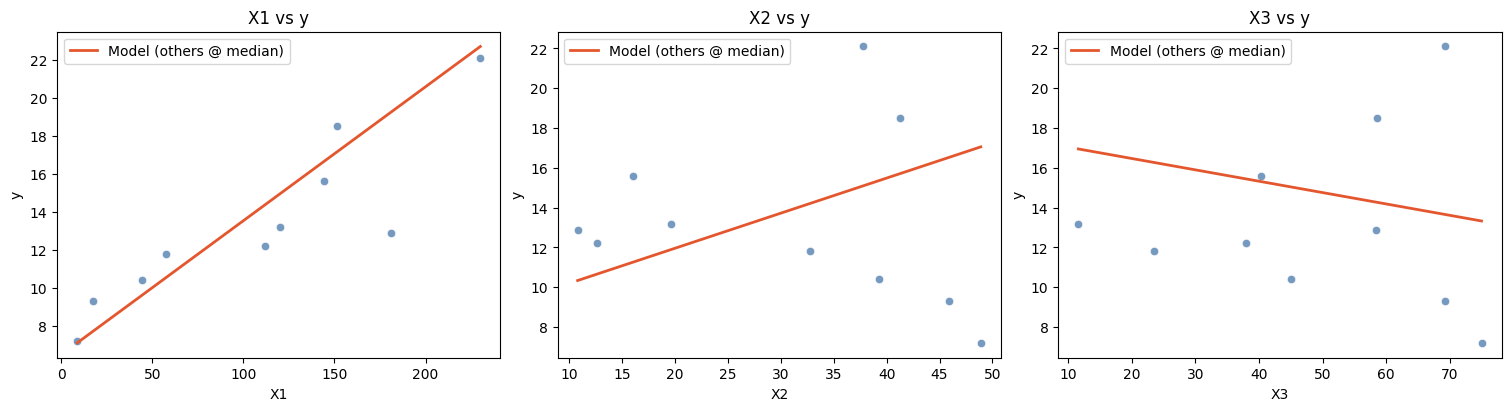

Coefficients (X1, X2, X3): [ 0.07045872  0.176354   -0.05711555]
Intercept: 3.2207019780103145
R^2: 0.9408001446975406


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
# Hold-two-constant-at-median, vary-one approach for model line
medians = df[["X1","X2","X3"]].median()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

features = ["X1", "X2", "X3"]
for ax, feat in zip(axes, features):
    # Scatter raw data
    ax.scatter(df[feat], df["y"], color="#3A6EA5", alpha=0.7, edgecolor="white", linewidth=0.6)

    # Build prediction line by varying 'feat' while fixing others at their medians
    x_min, x_max = df[feat].min(), df[feat].max()
    grid = np.linspace(x_min, x_max, 200)

    # Prepare batch for prediction
    X_pred = np.tile(medians.values, (grid.size, 1))
    idx = features.index(feat)
    X_pred[:, idx] = grid

    y_hat = model.predict(X_pred)

    ax.plot(grid, y_hat, color="#E4572E", lw=2, label="Model (others @ median)")
    ax.set_xlabel(feat)
    ax.set_ylabel("y")
    ax.set_title(f"{feat} vs y")
    ax.legend()

plt.show()

print("Coefficients (X1, X2, X3):", model.coef_)
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))